#BDA 355
#Final Project

In [ ]:
# run the following lines - Do not change lines!
names=input("Write your full names! ")# write your full name and your team member full name. e.g., Mark Fuller and Eli Rogers
print("names: ", names)

Write your full names! Vanessa Vega and Nishtha Patel
names:  Vanessa Vega and Nishtha Patel


##What is the goal of analysis?
A real state company wants to develop a regression model to predict the price of houses based on some specific features. Your task is to create a model with Python and write a professional report to explain the results.


In [ ]:
# import libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
file="https://bit.ly/BDA355_BostonHousing_f"

In [ ]:
df=pd.read_csv(file)

- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per 10,000 dollar
- PTRATIO - pupil-teacher ratio by town
- Type: Type of the home: detached, townhouse, and apartment
- LSTAT: percentage of lower status of the population
- MEDV: Median value of owner-occupied homes in $1000's

##Part 1: Data Understanding



In [ ]:
#do not change this cell
pd.set_option('display.max_colwidth', None)

In [ ]:
# view the top and the last 10 rows with head and tail functions
head=df.head(10)
tail=df.tail(10)


print(head)
print(tail)

      CRIM    ZN  INDUS  CHAS     NOX     RM   AGE     DIS  RAD    TAX  \
0  1.46336   0.0  19.58     0  0.6050  7.489  90.8  1.9709    5  403.0   
1  1.83377   0.0  19.58     1  0.6050  7.802  98.2  2.0407    5  403.0   
2  1.51902   0.0  19.58     1  0.6050  8.375  93.9  2.1620    5  403.0   
3  2.01019   0.0  19.58     0  0.6050  7.929  96.2  2.0459    5  403.0   
4  0.05602   0.0   2.46     0  0.4880  7.831  53.6  3.1992    3  193.0   
5  0.01381  80.0   0.46     0  0.4220  7.875  32.0  5.6484    4  255.0   
6  0.02009  95.0   2.68     0  0.4161  8.034  31.9  5.1180    4  224.0   
7  0.52693   0.0   6.20     0  0.5040  8.725  83.0  2.8944    8  307.0   
8  0.61154  20.0   3.97     0  0.6470  8.704  86.9  1.8010    5  264.0   
9  0.57834  20.0   3.97     0  0.5750  8.297  67.0  2.4216    5  264.0   

   PTRATIO  LSTAT  MEDV      Type  
0     14.7   1.73  50.0  detached  
1     14.7   1.92  50.0  detached  
2     14.7   3.32  50.0  detached  
3     14.7   3.70  50.0  detached  
4    

In [ ]:
#find the info for all variables using info() #run the cell
df.info





<bound method DataFrame.info of          CRIM   ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  \
0     1.46336  0.0  19.58     0  0.605  7.489   90.8  1.9709    5  403.0   
1     1.83377  0.0  19.58     1  0.605  7.802   98.2  2.0407    5  403.0   
2     1.51902  0.0  19.58     1  0.605  8.375   93.9  2.1620    5  403.0   
3     2.01019  0.0  19.58     0  0.605  7.929   96.2  2.0459    5  403.0   
4     0.05602  0.0   2.46     0  0.488  7.831   53.6  3.1992    3  193.0   
..        ...  ...    ...   ...    ...    ...    ...     ...  ...    ...   
501   0.18337  0.0  27.74     0  0.609  5.414   98.3  1.7554    4  711.0   
502   9.91655  0.0  18.10     0  0.693  5.852   77.8  1.5004   24  666.0   
503  25.04610  0.0  18.10     0  0.693  5.987  100.0  1.5888   24  666.0   
504  38.35180  0.0  18.10     0  0.693  5.453  100.0  1.4896   24  666.0   
505  67.92080  0.0  18.10     0  0.693  5.683  100.0  1.4254   24  666.0   

     PTRATIO  LSTAT  MEDV       Type  
0       14.7   1.73  50.0   detached  
1       14.7   1.92  50.0   detached  
2       14.7   3.32  50.0   detached  
3       14.7   3.70  50.0   detached  
4       17.8   4.45  50.0   detached  
..       ...    ...   ...        ...  
501     20.1  23.97   7.0  apartment  
502     20.2  29.97   6.3  apartment  
503     20.2  26.77   5.6  apartment  
504     20.2  30.59   5.0  apartment  
505     20.2  22.98   5.0  apartment  

[506 rows x 14 columns]>

In [ ]:
#find the shape of sample, sample size based on shape and number of variables based on shape results
shape=df.shape
sample_size= shape[0]
number_of_variables=shape[1]



print("shape:" , shape)
print("=========================================")
print("sample size: ", sample_size)
print("=========================================")
print("number of variables: ", number_of_variables)

shape: (506, 14)
sample size:  506
number of variables:  14


In [ ]:
#get statistics for scale(numeric) variables using describe() function
description=df.describe


print(description)

<bound method NDFrame.describe of          CRIM   ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  \
0     1.46336  0.0  19.58     0  0.605  7.489   90.8  1.9709    5  403.0   
1     1.83377  0.0  19.58     1  0.605  7.802   98.2  2.0407    5  403.0   
2     1.51902  0.0  19.58     1  0.605  8.375   93.9  2.1620    5  403.0   
3     2.01019  0.0  19.58     0  0.605  7.929   96.2  2.0459    5  403.0   
4     0.05602  0.0   2.46     0  0.488  7.831   53.6  3.1992    3  193.0   
..        ...  ...    ...   ...    ...    ...    ...     ...  ...    ...   
501   0.18337  0.0  27.74     0  0.609  5.414   98.3  1.7554    4  711.0   
502   9.91655  0.0  18.10     0  0.693  5.852   77.8  1.5004   24  666.0   
503  25.04610  0.0  18.10     0  0.693  5.987  100.0  1.5888   24  666.0   
504  38.35180  0.0  18.10     0  0.693  5.453  100.0  1.4896   24  666.0   
505  67.92080  0.0  18.10     0  0.693  5.683  100.0  1.4254   24  666.0   

     PTRATIO  LSTAT  MEDV       Type  
0       14.7  

In [ ]:
#find statistics (frequency) for the object variable (Type) using value_counts()
frequency=df["Type"].value_counts()



print(frequency)

Type
townhouse    265
detached     182
apartment     59
Name: count, dtype: int64


In [ ]:
# briefly describe sample, including sample size, statistics for dependent variable (mean, max, min, and std), and number of features - short lines/multiple lines
sample_description = f'''
The sample size is {sample_size}.
The dependent variable has a mean of {df["MEDV"].mean()}.
The maximum value is {df["MEDV"].max()}.
The minimum value is {df["MEDV"].min()}.
The standard deviation is {df["MEDV"].std()}.
The number of features is {number_of_variables}.
'''


print(sample_description)


The sample size is 506.
The dependent variable has a mean of 22.532806324110673.
The maximum value is 50.0.
The minimum value is 5.0.
The standard deviation is 9.19710408737982.
The number of features is 14.



##Part 2: Data Visualization
## Include 3 charts with insight for each chart

## Chart 1

### Plot a scatter plot for RM and the target variable

![image.png](https://drive.google.com/uc?id=1IoJSP5sPaB79WufaYQsym1pPIPIQR-kp)

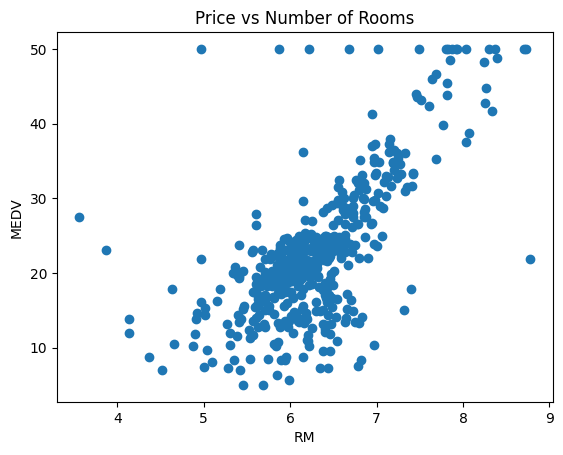

In [ ]:
# Write your code below
import matplotlib.pyplot as plt

plt.scatter(df["RM"], df["MEDV"])

plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Price vs Number of Rooms")


# do not change
plt.show()

In [ ]:
# write your insight from chart -short lines/multiple lines
chart_1_insight='''
The scatter plot shows a positive relationship between RM and MEDV.
As the number of rooms increases, the home value generally increases too.
Most homes are clustered around 5 to 7 rooms.
There are a few outliers, especially homes with high MEDV values near 50.
'''

print(chart_1_insight)


The scatter plot shows a positive relationship between RM and MEDV.
As the number of rooms increases, the home value generally increases too.
Most homes are clustered around 5 to 7 rooms.
There are a few outliers, especially homes with high MEDV values near 50.



## Chart 2

### Plot a scatter plot for LSTAT and the target variable

![image.png](https://drive.google.com/uc?id=1X92wWgnjem-cA3KOvQHcFLMxiSb5M5Lz)

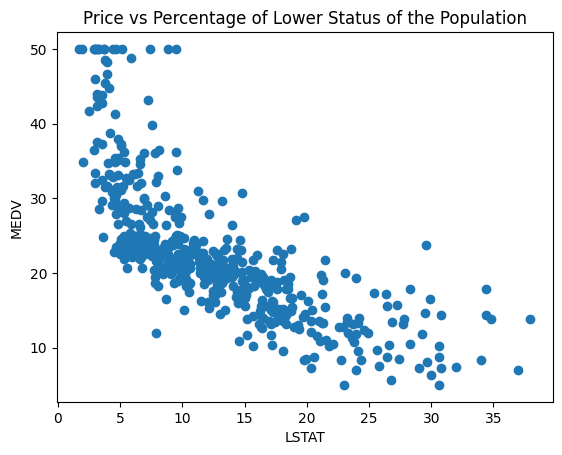

In [ ]:
# Write your code below

plt.scatter(df["LSTAT"], df["MEDV"])

plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.title("Price vs Percentage of Lower Status of the Population")
# do not change
plt.show()

In [ ]:
# write your insight from chart -short lines/multiple lines
chart_2_insight='''
The scatter plot shows a negative relationship between LSTAT and MEDV.
As the percentage of lower status population increases, home value generally decreases.
Homes with lower LSTAT values tend to have higher MEDV values.
There are a few outliers, but the overall trend is clearly downward.
'''

print(chart_2_insight)


The scatter plot shows a negative relationship between LSTAT and MEDV.
As the percentage of lower status population increases, home value generally decreases.
Homes with lower LSTAT values tend to have higher MEDV values.
There are a few outliers, but the overall trend is clearly downward.



## Chart 3

### Plot a bar chart for Type and the average of MEDV for each category of Type
![image.png](https://drive.google.com/uc?id=1IWDhJoyb-w-yVLluWfR6f9HbQyN2kDaq)


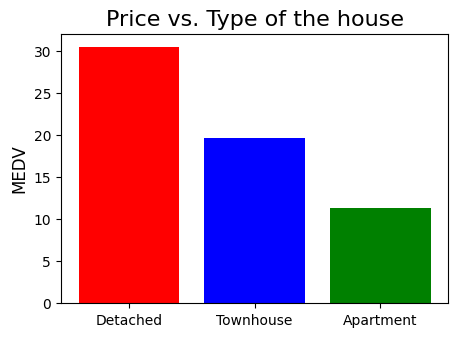

In [ ]:
# Write your code below
type_average = df.groupby("Type")["MEDV"].mean().sort_values(ascending=False)
type_labels = type_average.index.str.strip().str.capitalize()
colors = ["red", "blue", "green"]
plt.figure(figsize=(5, 3.5))
plt.bar(type_labels, type_average.values, color=colors, width=0.8)
plt.title("Price vs. Type of the house", fontsize=16)
plt.ylabel("MEDV", fontsize=12)
plt.xticks(rotation=0)

# do not change
plt.show()

In [ ]:
# write your insight from chart -short lines/multiple lines
chart_3_insight='''
Detached houses have the highest average price compared to the other house types.
Townhouses are in the middle, with a lower average price than detached homes.
Apartments have the lowest average price.
Overall, the chart suggests that house type has an impact on price.
'''

print(chart_3_insight)


Detached houses have the highest average price compared to the other house types.
Townhouses are in the middle, with a lower average price than detached homes.
Apartments have the lowest average price.
Overall, the chart suggests that house type has an impact on price.



##Part 3: Data Preparation

* report on missing values and handle them
* create a new variable: Type_num from Type (assign numbers to each category: 1 for apartment, 2 for townhouse, and 3 for detached)
* Check correlation for all variables. Explain the results of correlation analysis
> * which features are highly correlated with the dependent variable (absolute correlation more than 0.5)
> * which variables are moderately correlated with the dependant variable (absolute correlation between 0.3-0.5)
*	Check any multicollinearity issues (consider correlations above 0.75 as the threshold for multicollinearity) and remove those variables which are highly correlated to each other (when two variables are highly correlated, remove only one of them from your analysis)


In [ ]:
#missing values
missing_value=df.isnull().sum()


print(missing_value)

CRIM       5
ZN         3
INDUS      4
CHAS       0
NOX        1
RM         3
AGE        1
DIS        6
RAD        0
TAX        2
PTRATIO    1
LSTAT      4
MEDV       0
Type       0
dtype: int64


In [ ]:
#drop missing values using dropna, make sure to set inplace=True
df.dropna(inplace=True)



print(df.shape) # shape should be (476,14)

(476, 14)


In [ ]:
# create Type_num from Type using replace function-assign numbers to each category: 1 for apartment, 2 for townhouse, and 3 for detached
df["Type_num"]= df["Type"].replace({
    "apartment": 1,
    "townhouse": 2,
    "detached": 3
})




print(df.Type.value_counts())
print("=============================")
print(df.Type_num.value_counts())

Type
townhouse    249
detached     170
apartment     57
Name: count, dtype: int64
Type_num
2    249
3    170
1     57
Name: count, dtype: int64


In [ ]:
#check correlations
correlations=df.corr(numeric_only=True)



print(correlations)

              CRIM        ZN     INDUS      CHAS       NOX        RM  \
CRIM      1.000000 -0.198666  0.406780 -0.062694  0.413815 -0.222538   
ZN       -0.198666  1.000000 -0.535385 -0.036604 -0.512425  0.312018   
INDUS     0.406780 -0.535385  1.000000  0.057787  0.764051 -0.396073   
CHAS     -0.062694 -0.036604  0.057787  1.000000  0.081044  0.101165   
NOX       0.413815 -0.512425  0.764051  0.081044  1.000000 -0.302317   
RM       -0.222538  0.312018 -0.396073  0.101165 -0.302317  1.000000   
AGE       0.352868 -0.568653  0.646557  0.075632  0.736856 -0.235356   
DIS      -0.378440  0.668475 -0.704814 -0.096621 -0.768157  0.198817   
RAD       0.621704 -0.314732  0.603136 -0.018657  0.612192 -0.214700   
TAX       0.581199 -0.312229  0.717056 -0.046347  0.664270 -0.294490   
PTRATIO   0.293050 -0.396661  0.403102 -0.134471  0.189127 -0.356820   
LSTAT     0.454271 -0.411524  0.611111 -0.069101  0.591583 -0.612801   
MEDV     -0.387051  0.367053 -0.488391  0.191387 -0.428286  0.69

### Based on correlation results, answer the follwoing questions

In [ ]:
# Q1:which variables are highly correlated with MEDV? (correlation more than 0.5 -either positive or negative)-short lines/multiple lines
Q1='''
The variables highly correlated with MEDV are RM, PTRATIO, LSTAT, and Type_num.
RM and Type_num have a strong positive correlation with MEDV.
PTRATIO and LSTAT have a strong negative correlation with MEDV.
This means MEDV tends to increase as RM and Type_num increase, but decrease as PTRATIO and LSTAT increase.
'''

print(Q1)


The variables highly correlated with MEDV are RM, PTRATIO, LSTAT, and Type_num.
RM and Type_num have a strong positive correlation with MEDV.
PTRATIO and LSTAT have a strong negative correlation with MEDV.
This means MEDV tends to increase as RM and Type_num increase, but decrease as PTRATIO and LSTAT increase.



In [ ]:
# Q2:which variables are moderately correlated with MEDV? (correlation between 0.3 and 0.5 - either positive or negative) -short lines/multiple lines
Q2='''
The variables moderately correlated with MEDV are CRIM, ZN, INDUS, NOX, AGE, RAD, and TAX.
CRIM, INDUS, NOX, AGE, RAD, and TAX have moderate negative correlations with MEDV.
ZN has a moderate positive correlation with MEDV.
These results suggest that these variables have some relationship with MEDV, but not as strong as the highly correlated variables.
'''

print(Q2)


The variables moderately correlated with MEDV are CRIM, ZN, INDUS, NOX, AGE, RAD, and TAX.
CRIM, INDUS, NOX, AGE, RAD, and TAX have moderate negative correlations with MEDV.
ZN has a moderate positive correlation with MEDV.
These results suggest that these variables have some relationship with MEDV, but not as strong as the highly correlated variables.



In [ ]:
# Q3:which pairs of independent variables are highly correlated with each other? (correlation more than 0.75 - either positive or negative)-short lines/multiple lines
#do not change the below code


df_numeric = df.select_dtypes(include="number")
print((df_numeric.corr() > 0.75) | (df_numeric.corr() < -0.75))
print("================================================================================================")

Q3 = '''
The pairs of independent variables highly correlated with each other are INDUS and NOX.
NOX and DIS are also highly negatively correlated with each other.
AGE and DIS are highly negatively correlated with each other.
RAD and TAX are highly correlated with each other.

These pairs may cause multicollinearity issues because their correlations are above 0.75.
'''



#do not change print functions
print()
print(Q3)

           CRIM     ZN  INDUS   CHAS    NOX     RM    AGE    DIS    RAD  \
CRIM       True  False  False  False  False  False  False  False  False   
ZN        False   True  False  False  False  False  False  False  False   
INDUS     False  False   True  False   True  False  False  False  False   
CHAS      False  False  False   True  False  False  False  False  False   
NOX       False  False   True  False   True  False  False   True  False   
RM        False  False  False  False  False   True  False  False  False   
AGE       False  False  False  False  False  False   True   True  False   
DIS       False  False  False  False   True  False   True   True  False   
RAD       False  False  False  False  False  False  False  False   True   
TAX       False  False  False  False  False  False  False  False   True   
PTRATIO   False  False  False  False  False  False  False  False  False   
LSTAT     False  False  False  False  False  False  False  False  False   
MEDV      False  False  F

In [ ]:
# based on Q3, which variable or variables do you want to remove from your analysis to avoid multicolinearity. From each pair of variables, only remove one
# remove maximum 2 variables -short lines/multiple lines
Q4='''
To avoid multicollinearity, I would remove RAD and INDUS from the analysis.
RAD is highly correlated with TAX, so removing RAD keeps TAX.
INDUS is highly correlated with NOX, so removing INDUS keeps NOX.

This removes only one variable from each highly correlated pair.
'''


print(Q4)


To avoid multicollinearity, I would remove RAD and INDUS from the analysis.
RAD is highly correlated with TAX, so removing RAD keeps TAX.
INDUS is highly correlated with NOX, so removing INDUS keeps NOX.

This removes only one variable from each highly correlated pair.



In [ ]:
# drop that variable (those variables) from df using drop function
df_1=df.drop(columns=["RAD", "INDUS"])



#uncomment the below print function and run the cell
print(df_1.columns) #check to make sure that those variables that you dropped should not be in the list

Index(['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO',
       'LSTAT', 'MEDV', 'Type', 'Type_num'],
      dtype='object')


### We do not use df for the rest of analysis. Make sure to use df_1

In [ ]:
# create a dummy variable for Type from df_1, make sure to set drop_first=True
df_2=pd.get_dummies(df_1, columns=["Type"], drop_first=True)


#uncomment the below print function and run the cell
print(df_2.head())

      CRIM   ZN  CHAS    NOX     RM   AGE     DIS    TAX  PTRATIO  LSTAT  \
0  1.46336  0.0     0  0.605  7.489  90.8  1.9709  403.0     14.7   1.73   
1  1.83377  0.0     1  0.605  7.802  98.2  2.0407  403.0     14.7   1.92   
2  1.51902  0.0     1  0.605  8.375  93.9  2.1620  403.0     14.7   3.32   
3  2.01019  0.0     0  0.605  7.929  96.2  2.0459  403.0     14.7   3.70   
4  0.05602  0.0     0  0.488  7.831  53.6  3.1992  193.0     17.8   4.45   

   MEDV  Type_num  Type_detached  Type_townhouse  
0  50.0         3           True           False  
1  50.0         3           True           False  
2  50.0         3           True           False  
3  50.0         3           True           False  
4  50.0         3           True           False  


In [ ]:
# drop Type_num from df_2
df_ready=df_2.drop(columns=["Type_num"])


#uncomment the below print function and run the cell
print(df_ready.columns) #there should be no Type_num in the list

Index(['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO',
       'LSTAT', 'MEDV', 'Type_detached', 'Type_townhouse'],
      dtype='object')


### We do not use df_2 for rest of analysis. Make sure to use df_ready

##Part 4: Modeling

In [ ]:
# create X and y for OLS model from df_ready, y is MEDV and X is the rest of variables

y = df_ready["MEDV"]
X = df_ready.drop(columns=["MEDV"])


#uncomment the below print functions and run the cell
print(y.shape) # the shape should be (476,)
print(X.shape) #the shape should be (476,12) or (476,11) or (476,13)  it depends how many variables you dropped in the previous cell
print(X.columns) #should be all selected features except MEDV

(476,)
(476, 12)
Index(['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO',
       'LSTAT', 'Type_detached', 'Type_townhouse'],
      dtype='object')


In [ ]:
print(X.dtypes)

CRIM              float64
ZN                float64
CHAS                int64
NOX               float64
RM                float64
AGE               float64
DIS               float64
TAX               float64
PTRATIO           float64
LSTAT             float64
Type_detached        bool
Type_townhouse       bool
dtype: object


In [ ]:
# create OLS model
# first, we add constant to X. Uncomment the below code
X=sm.add_constant(X)
X = X.astype(float)
y = y.astype(float)

#Now, create the model with y and X and then fit()
model_ols = sm.OLS(y, X).fit()





In [ ]:
#do not change this cell. Uncomment the below print function and Run the cell
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     126.9
Date:                Wed, 06 May 2026   Prob (F-statistic):          6.12e-138
Time:                        10:23:29   Log-Likelihood:                -1386.0
No. Observations:                 476   AIC:                             2798.
Df Residuals:                     463   BIC:                             2852.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             26.6321      4.781      5.

##Answer the following questions based on model_ols.summary() results

In [ ]:
#Q5: which variables are significant? -short lines/multiple lines
Q5='''The significant variables in the model are: ZN, CHAS, NOX, RM, DIS, PTRATIO, LSTAT,
Type_detached, and Type_townhouse (all have p-values below 0.05).
CRIM, AGE, and TAX are NOT significant (p-values of 0.128, 0.418, and 0.823 respectively).'''
print(Q5)

The significant variables in the model are: ZN, CHAS, NOX, RM, DIS, PTRATIO, LSTAT,
Type_detached, and Type_townhouse (all have p-values below 0.05).
CRIM, AGE, and TAX are NOT significant (p-values of 0.128, 0.418, and 0.823 respectively).


In [ ]:
#Q6: what is R-squared of the model? -short lines/multiple lines
Q6='''The R-squared of the model is 0.767.
This means the model explains approximately 76.7% of the variance in home prices (MEDV).
The Adjusted R-squared is 0.761, which accounts for the number of predictors in the model.'''

print(Q6)

The R-squared of the model is 0.767.
This means the model explains approximately 76.7% of the variance in home prices (MEDV).
The Adjusted R-squared is 0.761, which accounts for the number of predictors in the model.


In [ ]:
#Q7: what does Prob (F-statistic) suggest? -short lines/multiple lines
Q7='''The Prob (F-statistic) is 6.12e-138, which is essentially 0 and far below 0.05.
This means the overall model is statistically significant.
At least one predictor variable has a meaningful relationship with the dependent variable MEDV.'''

print(Q7)

The Prob (F-statistic) is 6.12e-138, which is essentially 0 and far below 0.05.
This means the overall model is statistically significant.
At least one predictor variable has a meaningful relationship with the dependent variable MEDV.


In [ ]:
#Q8: what does Prob (Omnibus) suggest? -short lines/multiple lines
Q8='''The Prob (Omnibus) is 0.000, which is below 0.05.
This means the residuals are NOT normally distributed.
This violates one of the key assumptions of OLS regression and may affect the
reliability of the model's statistical tests.'''

print(Q8)

The Prob (Omnibus) is 0.000, which is below 0.05.
This means the residuals are NOT normally distributed.
This violates one of the key assumptions of OLS regression and may affect the
reliability of the model's statistical tests.


In [ ]:
#Q9: what does Durbin-Watson suggest? -short lines/multiple lines
Q9='''The Durbin-Watson statistic is 1.067.
The ideal range is between 1.5 and 2.5, indicating no autocorrelation.
Since 1.067 falls below this range, there is positive autocorrelation in the residuals.
This violates the OLS independence assumption and may reduce the reliability of the model.'''

print(Q9)

The Durbin-Watson statistic is 1.067.
The ideal range is between 1.5 and 2.5, indicating no autocorrelation.
Since 1.067 falls below this range, there is positive autocorrelation in the residuals.
This violates the OLS independence assumption and may reduce the reliability of the model.


##Part 5: Model Evaluation

### Use split method (0.7, 0.3)
### Report quality metrics inclusing R-Squared and MSE for training and test.
### Explain in a short paragraph if there is any overfitting or underfitting issue based on model evaluation results.

In [ ]:
#split data into train and test
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

X_sk = df_ready.drop(columns=["MEDV"])
y = df_ready["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X_sk, y, test_size=0.3, random_state=42)



In [ ]:
#create a Linear Regression model
reg = LinearRegression()

#fit your model based X_train and y_train
model = reg.fit(X_train, y_train)


#Uncomment the below code and run the cell
print(model.get_params)

<bound method BaseEstimator.get_params of LinearRegression()>


In [ ]:
# find the prediction values (training_y_pred) based on X_train

training_y_pred = model.predict(X_train)

print(training_y_pred.shape)

(333,)


In [ ]:
# find mean squared error and R-squared for training dataset

training_r2  = r2_score(y_train, training_y_pred)
training_mse = mean_squared_error(y_train, training_y_pred)
print("training_mse: ", training_mse)
print("training_r2: ",  training_r2)

training_mse:  16.205426720361892
training_r2:  0.7804288330516719


In [ ]:
# find the prediction values (test_y_pred) based on X_test

test_y_pred = model.predict(X_test)

print(test_y_pred.shape)

(143,)
test_mse:  30.56754534841126
test_r2:  0.7206386980766075


In [ ]:
# find mean squared error and R-squared for test dataset

test_r2  = r2_score(y_test, test_y_pred)
test_mse = mean_squared_error(y_test, test_y_pred)
print("test_mse: ", test_mse)
print("test_r2: ",  test_r2)

test_mse:  30.56754534841126
test_r2:  0.7206386980766075


##Based on results of training and test R-Squared and MSE, explain what is your evaluation of the model in terms of underfitting or overfitting

In [ ]:
#type your evaluation here -short lines/multiple lines
evaluation='''The training R-squared is 0.780 and the test R-squared is 0.721.
The training MSE is 16.21 and the test MSE is 30.57.
The drop in R-squared (0.780 to 0.721) and the near doubling of MSE (16.21 to 30.57)
from training to test suggests mild overfitting.
The model fits the training data better than unseen data, but the difference is
not extreme, so the model still generalizes reasonably well overall.'''


print(evaluation)

The training R-squared is 0.780 and the test R-squared is 0.721.
The training MSE is 16.21 and the test MSE is 30.57.
The drop in R-squared (0.780 to 0.721) and the near doubling of MSE (16.21 to 30.57)
from training to test suggests mild overfitting.
The model fits the training data better than unseen data, but the difference is
not extreme, so the model still generalizes reasonably well overall.


## Part 6: Recommendation for model improvement

In [ ]:
# type your recommendations for improving the model (at least 3) -short lines/multiple lines
recommendations='''
1. Remove insignificant variables (CRIM, AGE, and TAX) since their p-values
   (0.128, 0.418, and 0.823) indicate they do not significantly contribute
   to predicting MEDV. Removing them may reduce overfitting.

2. Address the non-normality of residuals (Prob Omnibus = 0.000) by applying
   a log transformation to MEDV. This may stabilize variance and better
   satisfy the OLS normality assumption.

3. Address the positive autocorrelation (Durbin-Watson = 1.067) by exploring
   additional neighborhood or location-based features that may capture
   spatial patterns in the data.

4. Apply cross-validation (e.g., k-fold) instead of a single train/test split
   to get a more reliable estimate of model performance and reduce the gap
   between training MSE (16.21) and test MSE (30.57).

5. Try polynomial or interaction features such as RM x LSTAT to capture
   non-linear relationships, which may improve the test R-squared beyond 0.721.
'''

print(recommendations)


1. Remove insignificant variables (CRIM, AGE, and TAX) since their p-values
   (0.128, 0.418, and 0.823) indicate they do not significantly contribute
   to predicting MEDV. Removing them may reduce overfitting.

2. Address the non-normality of residuals (Prob Omnibus = 0.000) by applying
   a log transformation to MEDV. This may stabilize variance and better
   satisfy the OLS normality assumption.

3. Address the positive autocorrelation (Durbin-Watson = 1.067) by exploring
   additional neighborhood or location-based features that may capture
   spatial patterns in the data.

4. Apply cross-validation (e.g., k-fold) instead of a single train/test split
   to get a more reliable estimate of model performance and reduce the gap
   between training MSE (16.21) and test MSE (30.57).

5. Try polynomial or interaction features such as RM x LSTAT to capture
   non-linear relationships, which may improve the test R-squared beyond 0.721.



## Part 7: New Predictions

### Based on the resluts of the model_ols, predict the price for the follwoing new data.

### new data
> * constant=1
> * CRIM=0.17899
> * ZN=0
> * INDUS=9.69
> * CHAS=0
> * NOX=0.585
> * RM=5.67
> * AGE=28.8
> * DIS=2.7986
> * RAD=6
> * TAX=391
> * PTRATIO=19.2
> * LSTAT=17.6
> * TYPE=apartment

In [ ]:
# you can do it manually here or using model_ols.predict(new_data)
# write your calculations or code below -short lines/multiple lines

# TYPE = apartment means Type_detached=0 and Type_townhouse=0

new_data = pd.DataFrame(
    [[1, 0.17899, 0, 0, 0.585, 5.67, 28.8, 2.7986, 391, 19.2, 17.6, 0, 0]],
    columns=['const','CRIM','ZN','CHAS','NOX','RM','AGE','DIS',
             'TAX','PTRATIO','LSTAT','Type_detached','Type_townhouse']
)
new_data = new_data.astype(float)

predicted_price = model_ols.predict(new_data)
print("Predicted MEDV:", round(predicted_price[0], 2))


print()

Q10='''The predicted median home value for this new house is approximately $13,370.
The house is an apartment, so it does not receive any bonus for being a
detached home or townhouse, which keeps the price lower.
The high percentage of lower status population (LSTAT = 17.6) and high
pupil-teacher ratio (PTRATIO = 19.2) pull the price down the most.
INDUS and RAD were not included because they were removed earlier
since they were too closely related to other variables already in the model.
'''


print(Q10)

Predicted MEDV: 13.37

The predicted median home value for this new house is approximately $13,370.
The house is an apartment, so it does not receive any bonus for being a
detached home or townhouse, which keeps the price lower.
The high percentage of lower status population (LSTAT = 17.6) and high
pupil-teacher ratio (PTRATIO = 19.2) pull the price down the most.
INDUS and RAD were not included because they were removed earlier
since they were too closely related to other variables already in the model.

